# Task 4 - Step 3: Open-set evaluation (first and only use of CIFAR-100 unknowns)

`task4.data.cifar100_unknowns.load_unknowns(freeze_manifest)` re-hashes every checkpoint, config, saved output,
Mahalanobis state and threshold file from notebook 02 and refuses if anything changed; each access is logged to
`data/cifar/unknown_access_log.jsonl`. Only the CIFAR-100 **test** split is used (800 near + 800 far images).

Nothing computed here may revise a model, a score definition or a threshold.

In [1]:
# ---- Task 4 common header (identical in every Task 4 notebook) ----
# NOTE: no CIFAR-100 image is decoded or loaded anywhere except notebook 03, after the freeze check.
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "task4" / "training.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared.config import load_config
from task4.data import cifar10
from task4.models.resnet_cifar import build_model

T4 = REPO / "task4"
CFG_DIR = T4 / "configs"
SEED = 6304
# Smoke mode (env TASK4_SMOKE=1): 2 epochs on 2000 training images; outputs under _smoke/; notebook 03 uses
# RANDOM stand-in "unknown" images, so no CIFAR-100 image is touched.
SMOKE = os.environ.get("TASK4_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T4 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T4 / "results" / "tables"       # data-preparation files (same path in smoke and real mode)
DATA_TAB.mkdir(parents=True, exist_ok=True)
CKPT = T4 / "checkpoints" / SUB            # git-ignored
CACHE = T4 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RUNS = ["vanilla", "gcsc", "proser"]
LABEL = {"vanilla": "Vanilla", "gcsc": "GCSC", "proser": "PROSER"}
SCORES = ["msp", "mls", "energy", "mahalanobis"]         # post-hoc scores on the frozen Vanilla model
SCORE_LABEL = {"msp": "MSP", "mls": "MLS", "energy": "Energy", "mahalanobis": "Mahalanobis",
               "placeholder": "PROSER placeholder"}


def run_dir(n):
    return CKPT / load_config(CFG_DIR, n)["run_name"]


def load_trained(n):
    """Frozen model with the selected checkpoint of run ``n``."""
    cfg = load_config(CFG_DIR, n)
    ck = torch.load(run_dir(n) / "best.pt", map_location="cpu", weights_only=False)
    model = build_model(cfg["model"]["num_classes"], cfg["model"]["dummy_classifiers"], cfg["seed"])
    model.load_state_dict(ck["model"])
    return model.to(DEVICE).eval(), ck, cfg


@torch.no_grad()
def extract(model, x_u8, batch_size=512):
    """Penultimate features and logits of a frozen model (no augmentation)."""
    feats, logits = [], []
    for s in range(0, len(x_u8), batch_size):
        f, z = model(cifar10.normalize(x_u8[s:s + batch_size].to(DEVICE)))
        feats.append(f.float().cpu()); logits.append(z.float().cpu())
    return torch.cat(feats), torch.cat(logits)


plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
from task4.evaluation.metrics import auroc, fpr_at_95tpr, osr_row
from task4.scores import MahalanobisScore, POST_HOC

K = 10
blob_k = torch.load(CACHE / "known_outputs.pt", weights_only=False)
OUT, CSA = blob_k["outputs"], blob_k["csa"]
SCORES_KNOWN = torch.load(CACHE / "known_scores.pt", weights_only=False)["scores_known"]
THRESH = pd.read_csv(TAB / "task4_thresholds.csv")
mah = MahalanobisScore(); st = torch.load(CACHE / "mahalanobis_vanilla.pt", weights_only=False)
mah.means, mah.inv_var, mah.eps = st["means"], st["inv_var"], st["eps"]

if SMOKE:
    g = torch.Generator().manual_seed(0)
    UNK = {grp: (torch.randint(0, 256, (64, 3, 32, 32), dtype=torch.uint8, generator=g), ["fake"] * 64)
           for grp in ("near", "far")}
    print("SMOKE MODE: random stand-in unknowns - no CIFAR-100 image touched")
else:
    from task4.data import cifar100_unknowns as unk
    print(json.dumps(unk.prepare(), indent=1))                       # decodes the CIFAR-100 TEST split only
    UNK = unk.load_unknowns(CACHE / "freeze_manifest.json")           # verifies the freeze, logs the access
print({g_: len(v[1]) for g_, v in UNK.items()})

{
 "parquet_sha256": "98776c529bb146a9c791229df74a5cf076be9b43d82dbbd334b6a7788d73dc68",
 "split_used": "test only",
 "counts": {
  "near": 800,
  "far": 800
 },
 "per_class": {
  "near": {
   "bus": 100,
   "pickup_truck": 100,
   "motorcycle": 100,
   "tractor": 100,
   "wolf": 100,
   "fox": 100,
   "leopard": 100,
   "camel": 100
  },
  "far": {
   "bottle": 100,
   "bowl": 100,
   "chair": 100,
   "clock": 100,
   "keyboard": 100,
   "mushroom": 100,
   "sunflower": 100,
   "wardrobe": 100
  }
 }
}


{'near': 800, 'far': 800}


In [3]:
UNK_OUT, UNK_SCORES = {}, {}
for n in RUNS:
    model, ck, cfg = load_trained(n)
    UNK_OUT[n] = {}
    for grp, (x, names) in UNK.items():
        f, z = extract(model, x)
        UNK_OUT[n][grp] = {"feat": f, "logits": z, "class_names": names}
    del model
    UNK_SCORES[n] = {}
    for grp in UNK:
        z, f = UNK_OUT[n][grp]["logits"][:, :K], UNK_OUT[n][grp]["feat"]
        s = {name: fn(z).numpy() for name, fn in POST_HOC.items()}
        if n == "vanilla":
            s["mahalanobis"] = mah(f).numpy()
        if n == "proser":
            s["placeholder"] = (UNK_OUT[n][grp]["logits"][:, K:].max(1).values - z.max(1).values).numpy()
        UNK_SCORES[n][grp] = s
print("scored:", {n: list(UNK_SCORES[n]["near"]) for n in RUNS})

scored: {'vanilla': ['msp', 'mls', 'energy', 'mahalanobis'], 'gcsc': ['msp', 'mls', 'energy'], 'proser': ['msp', 'mls', 'energy', 'placeholder']}


## 3.1 Required table 1: MSP vs MLS vs Energy vs Mahalanobis on the frozen Vanilla model

In [4]:
def rows_for(run, score_keys):
    out = []
    for s in score_keys:
        r = osr_row(SCORES_KNOWN[run]["val"][s], SCORES_KNOWN[run]["test"][s],
                    UNK_SCORES[run]["near"][s], UNK_SCORES[run]["far"][s])
        out.append({"model": LABEL[run], "config": run, "score": SCORE_LABEL[s], "score_key": s,
                    "cifar10_test_csa": CSA[run], **r})
    return out


VANILLA_SCORES = pd.DataFrame(rows_for("vanilla", SCORES))
VANILLA_SCORES.to_csv(TAB / "task4_score_comparison.csv", index=False)
VANILLA_SCORES[["score", "auroc_known_vs_near", "auroc_known_vs_far", "auroc_known_vs_all", "threshold",
                "test_acceptance_rate", "near_rejection_rate", "far_rejection_rate", "fpr_at_95tpr_all"]].round(4)

,score,auroc_known_vs_near,auroc_known_vs_far,auroc_known_vs_all,threshold,test_acceptance_rate,near_rejection_rate,far_rejection_rate,fpr_at_95tpr_all
0,MSP,0.8174,0.9010,0.8592,0.1535,0.9469,0.2825,0.4300,0.6525
1,MLS,0.7921,0.8983,0.8452,-5.9302,0.9494,0.3088,0.5162,0.5906
2,Energy,0.7920,0.8989,0.8454,-6.0661,0.9532,0.2962,0.5125,0.5850
3,Mahalanobis,0.8020,0.9194,0.8607,2951.2963,0.9467,0.2912,0.5188,0.6112


## 3.2 Required table 2: Vanilla vs GCSC vs PROSER with MLS (+ the PROSER placeholder score)

In [5]:
rows = rows_for("vanilla", ["mls"]) + rows_for("gcsc", ["mls"]) + rows_for("proser", ["mls"]) + rows_for("proser", ["placeholder"])
MODEL_CMP = pd.DataFrame(rows)
MODEL_CMP.to_csv(TAB / "task4_osr_metrics.csv", index=False)
MODEL_CMP[["model", "score", "cifar10_test_csa", "auroc_known_vs_near", "auroc_known_vs_far", "auroc_known_vs_all",
           "test_acceptance_rate", "near_rejection_rate", "far_rejection_rate", "fpr_at_95tpr_all"]].round(4)

,model,score,cifar10_test_csa,auroc_known_vs_near,auroc_known_vs_far,auroc_known_vs_all,test_acceptance_rate,near_rejection_rate,far_rejection_rate,fpr_at_95tpr_all
0,Vanilla,MLS,0.9461,0.7921,0.8983,0.8452,0.9494,0.3088,0.5162,0.5906
1,GCSC,MLS,0.9543,0.8337,0.9100,0.8719,0.9476,0.3750,0.6088,0.5175
2,PROSER,MLS,0.9440,0.8006,0.8637,0.8321,0.9485,0.3025,0.4225,0.6438
3,PROSER,PROSER placeholder,0.9440,0.7868,0.8874,0.8371,0.9494,0.2900,0.4600,0.6256


## 3.3 Score distributions and ROC curves (MSP, MLS, Mahalanobis on Vanilla)

saved figure task4_score_distributions


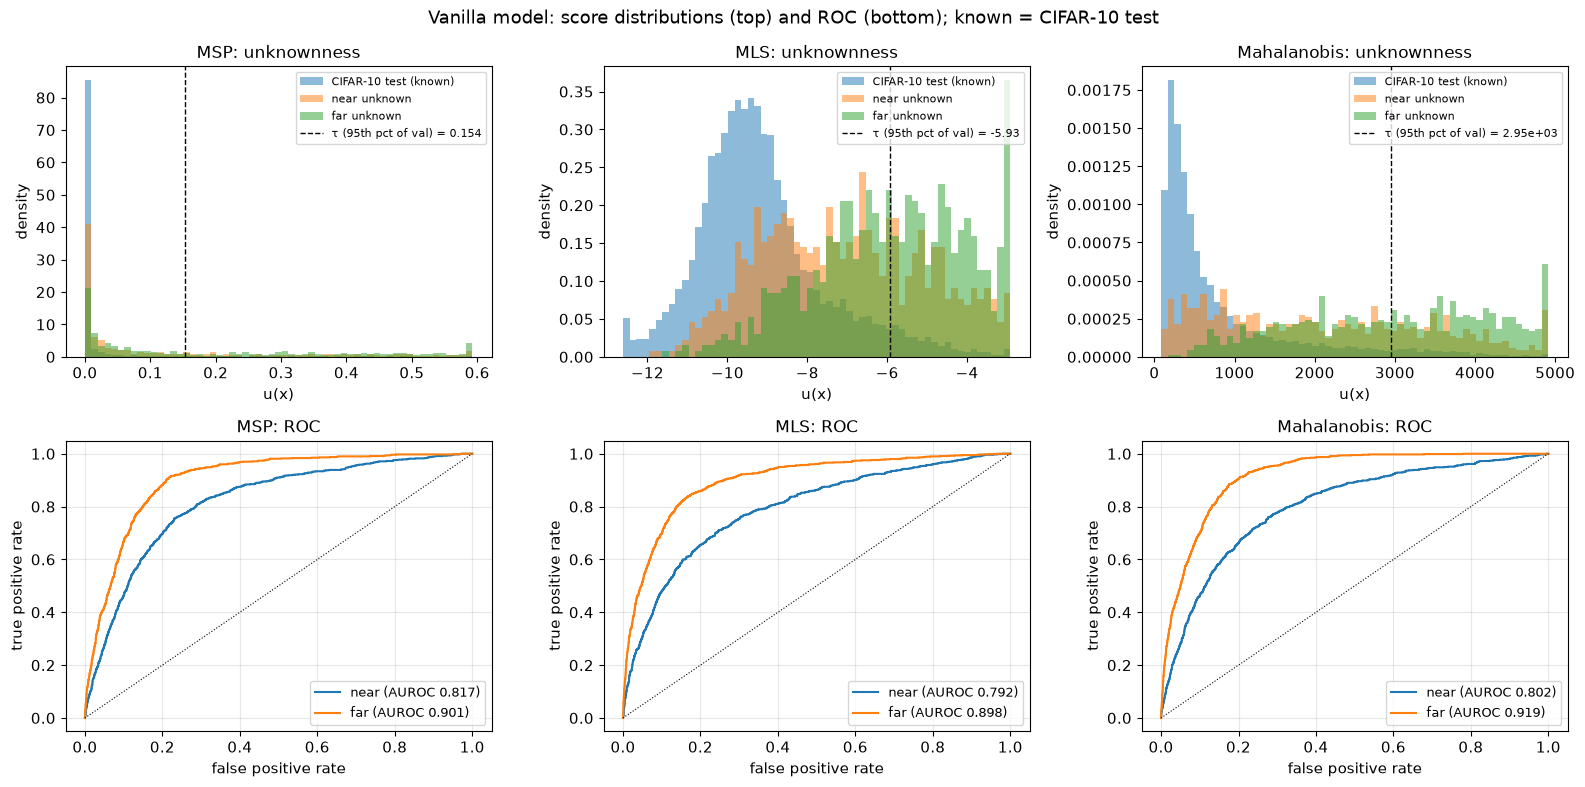

In [6]:
from sklearn.metrics import roc_curve
show = ["msp", "mls", "mahalanobis"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, s in enumerate(show):
    ut, un, uf = SCORES_KNOWN["vanilla"]["test"][s], UNK_SCORES["vanilla"]["near"][s], UNK_SCORES["vanilla"]["far"][s]
    tau = float(THRESH[(THRESH.config == "vanilla") & (THRESH.score_key == s)].threshold_tau.iloc[0])
    lo, hi = np.percentile(np.concatenate([ut, un, uf]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    ax = axes[0, j]
    for u, lab, c in [(ut, "CIFAR-10 test (known)", "tab:blue"), (un, "near unknown", "tab:orange"), (uf, "far unknown", "tab:green")]:
        ax.hist(np.clip(u, lo, hi), bins=bins, density=True, alpha=.5, label=lab, color=c)
    ax.axvline(tau, color="k", ls="--", lw=1, label=f"τ (95th pct of val) = {tau:.3g}")
    ax.set_title(f"{SCORE_LABEL[s]}: unknownness"); ax.set_xlabel("u(x)"); ax.set_ylabel("density"); ax.legend(fontsize=8)
    ax = axes[1, j]
    for u, lab in [(un, "near"), (uf, "far")]:
        fpr, tpr, _ = roc_curve(np.concatenate([np.zeros(len(ut)), np.ones(len(u))]), np.concatenate([ut, u]))
        ax.plot(fpr, tpr, label=f"{lab} (AUROC {auroc(ut, u):.3f})")
    ax.plot([0, 1], [0, 1], "k:", lw=.8); ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.set_title(f"{SCORE_LABEL[s]}: ROC"); ax.legend(fontsize=9); ax.grid(alpha=.3)
fig.suptitle("Vanilla model: score distributions (top) and ROC (bottom); known = CIFAR-10 test")
plt.tight_layout(); savefig(fig, "task4_score_distributions"); plt.show()

## 3.4 Near vs far, per unknown class

In [7]:
rows = []
for n in RUNS:
    for grp in UNK:
        s_key = "mls"
        u = UNK_SCORES[n][grp][s_key]
        tau = float(THRESH[(THRESH.config == n) & (THRESH.score_key == s_key)].threshold_tau.iloc[0])
        names = np.asarray(UNK[grp][1])
        pred = UNK_OUT[n][grp]["logits"][:, :K].argmax(1).numpy()
        for c in sorted(set(names.tolist())):
            m = names == c
            rows.append({"config": n, "model": LABEL[n], "score": SCORE_LABEL[s_key], "group": grp, "unknown_class": c,
                         "n": int(m.sum()), "acceptance_rate": float((u[m] <= tau).mean()),
                         "rejection_rate": float((u[m] > tau).mean()), "mean_unknownness": float(u[m].mean()),
                         "most_common_cifar10_prediction": cifar10.class_names()[int(np.bincount(pred[m], minlength=K).argmax())]})
PER_CLASS = pd.DataFrame(rows)
PER_CLASS.to_csv(TAB / "task4_unknown_class_analysis.csv", index=False)
PER_CLASS[PER_CLASS.config == "vanilla"].round(3)

,config,model,score,group,unknown_class,n,acceptance_rate,rejection_rate,mean_unknownness,most_common_cifar10_prediction
0,vanilla,Vanilla,MLS,near,bus,100,0.88,0.12,-8.369,truck
1,vanilla,Vanilla,MLS,near,camel,100,0.59,0.41,-6.488,horse
2,vanilla,Vanilla,MLS,near,fox,100,0.73,0.27,-7.068,deer
3,vanilla,Vanilla,MLS,near,leopard,100,0.61,0.39,-6.724,cat
4,vanilla,Vanilla,MLS,near,motorcycle,100,0.35,0.65,-5.484,automobile
5,vanilla,Vanilla,MLS,near,pickup_truck,100,0.93,0.07,-8.098,automobile
6,vanilla,Vanilla,MLS,near,tractor,100,0.61,0.39,-6.518,truck
7,vanilla,Vanilla,MLS,near,wolf,100,0.83,0.17,-7.802,cat
8,vanilla,Vanilla,MLS,far,bottle,100,0.41,0.59,-5.683,cat
9,vanilla,Vanilla,MLS,far,bowl,100,0.50,0.50,-6.072,cat


saved figure task4_unknown_class_acceptance


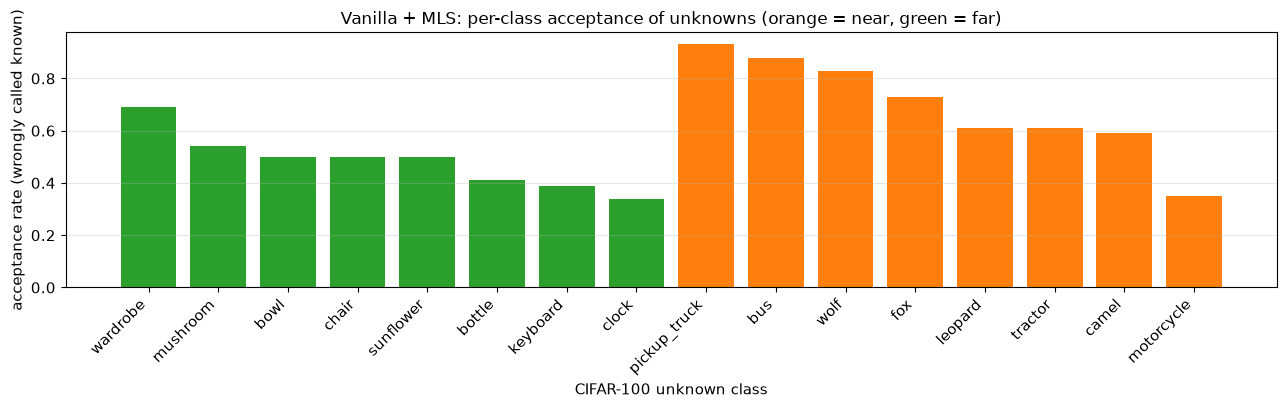

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.2))
sub = PER_CLASS[PER_CLASS.config == "vanilla"].sort_values(["group", "acceptance_rate"], ascending=[True, False])
colors = ["tab:orange" if g == "near" else "tab:green" for g in sub.group]
ax.bar(range(len(sub)), sub.acceptance_rate, color=colors)
ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.unknown_class, rotation=45, ha="right")
ax.set_ylabel("acceptance rate (wrongly called known)"); ax.set_xlabel("CIFAR-100 unknown class")
ax.set_title("Vanilla + MLS: per-class acceptance of unknowns (orange = near, green = far)")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "task4_unknown_class_acceptance"); plt.show()

## 3.5 Failure analysis: unknowns accepted under the Vanilla MLS threshold

Required: at least three near and three far unknowns that are wrongly accepted, with the unknown class, the predicted
CIFAR-10 class, the score and the threshold. `same_supercategory` is a factual helper (animal / vehicle / object
grouping); whether a confusion is *semantically plausible* is left to the report.

In [9]:
SUPER10 = {"airplane": "vehicle", "automobile": "vehicle", "bird": "animal", "cat": "animal", "deer": "animal",
           "dog": "animal", "frog": "animal", "horse": "animal", "ship": "vehicle", "truck": "vehicle"}
SUPER100 = {**{c: "vehicle" for c in ["bus", "pickup_truck", "motorcycle", "tractor"]},
            **{c: "animal" for c in ["wolf", "fox", "leopard", "camel"]},
            **{c: "object" for c in ["bottle", "bowl", "chair", "clock", "keyboard", "mushroom", "sunflower", "wardrobe"]}}
cls10 = cifar10.class_names()
tau_v = float(THRESH[(THRESH.config == "vanilla") & (THRESH.score_key == "mls")].threshold_tau.iloc[0])
rows = []
for grp in UNK:
    u = UNK_SCORES["vanilla"][grp]["mls"]
    z = UNK_OUT["vanilla"][grp]["logits"][:, :K]
    pred, conf = z.argmax(1).numpy(), z.softmax(1).max(1).values.numpy()
    names = np.asarray(UNK[grp][1])
    accepted = np.flatnonzero(u <= tau_v)
    for i in accepted[np.argsort(u[accepted])][:10]:                 # most confidently accepted first
        rows.append({"group": grp, "index": int(i), "unknown_class": str(names[i]),
                     "predicted_cifar10_class": cls10[int(pred[i])], "softmax_confidence": float(conf[i]),
                     "mls_unknownness": float(u[i]), "threshold": tau_v,
                     "same_supercategory": SUPER100.get(str(names[i])) == SUPER10[cls10[int(pred[i])]],
                     "unknown_supercategory": SUPER100.get(str(names[i]), "?"),
                     "predicted_supercategory": SUPER10[cls10[int(pred[i])]]})
FAIL = pd.DataFrame(rows)
FAIL.to_csv(TAB / "task4_failure_cases.csv", index=False)
print("accepted unknowns listed:", dict(FAIL.group.value_counts()))
FAIL.round(4)

accepted unknowns listed: {'near': np.int64(10), 'far': np.int64(10)}


,group,index,unknown_class,predicted_cifar10_class,softmax_confidence,mls_unknownness,threshold,same_supercategory,unknown_supercategory,predicted_supercategory
0,near,562,bus,truck,1.0000,-11.9202,-5.9302,True,vehicle,vehicle
1,near,308,bus,truck,1.0000,-11.6283,-5.9302,True,vehicle,vehicle
2,near,410,bus,truck,0.9998,-11.4554,-5.9302,True,vehicle,vehicle
3,near,730,pickup_truck,automobile,0.9999,-11.1663,-5.9302,True,vehicle,vehicle
4,near,321,bus,truck,1.0000,-11.1560,-5.9302,True,vehicle,vehicle
5,near,401,leopard,cat,0.9999,-11.0937,-5.9302,True,animal,animal
6,near,743,leopard,frog,0.9999,-11.0690,-5.9302,True,animal,animal
7,near,391,wolf,dog,0.9999,-11.0526,-5.9302,True,animal,animal
8,near,82,camel,horse,0.9999,-10.9472,-5.9302,True,animal,animal
9,near,504,bus,truck,0.9999,-10.8899,-5.9302,True,vehicle,vehicle


saved figure task4_failure_cases


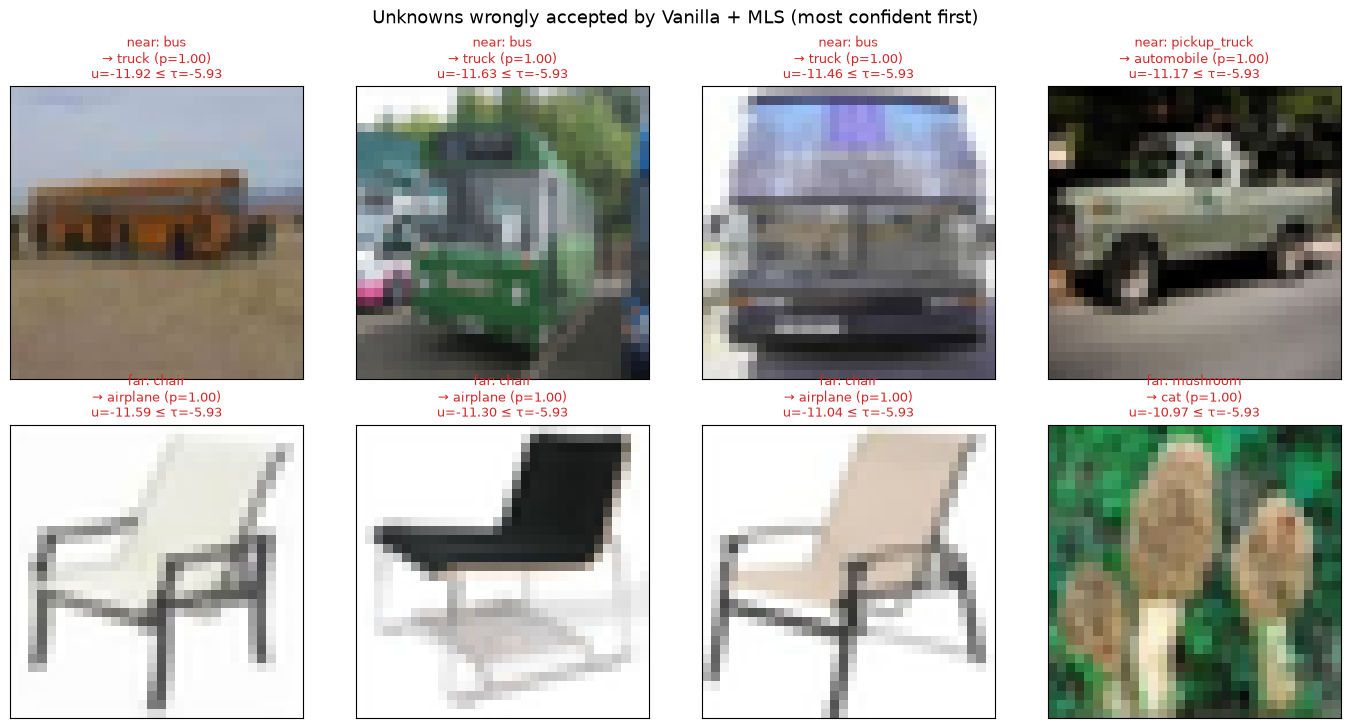

In [10]:
show = pd.concat([FAIL[FAIL.group == "near"].head(4), FAIL[FAIL.group == "far"].head(4)])
fig, axes = plt.subplots(2, 4, figsize=(14, 7.4))
for ax, (_, r) in zip(axes.ravel(), show.iterrows()):
    ax.imshow(UNK[r.group][0][int(r["index"])].permute(1, 2, 0).numpy()); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{r.group}: {r.unknown_class}\n→ {r.predicted_cifar10_class} (p={r.softmax_confidence:.2f})\n"
                 f"u={r.mls_unknownness:.2f} ≤ τ={r.threshold:.2f}", fontsize=9, color="tab:red")
for ax in axes.ravel()[len(show):]:
    ax.axis("off")
fig.suptitle("Unknowns wrongly accepted by Vanilla + MLS (most confident first)")
plt.tight_layout(); savefig(fig, "task4_failure_cases"); plt.show()